# Pre-process step 1
- This pre processing step first rotates the full frame to flatten the spectrum using rotations transformation.
- Following rotation, the image is affine transformed to straighten the skew in the slit due to the prism.
- Needs: Calibration sequence (folder in data/session_id/fib/ called CalibrationFiles.
    - Acquire calibration sequence after any modifications to the system or at the start of every month if no modifications are made.
    - Turn on all lasers and acquire a short sequence at full frame.
- CalibrationFiles contains:
    - session_params.csv
    - A subfolder called Tiffs with tiffs named Tiffs0.tif, Tiffs1.tif, Tiffs2.tif, etc
- Saves: 
    - A .tiff file with the final calibrated image.
    - a .txt file with the transformation points.


In [4]:
import pandas as pd
import numpy as np
import os
import glob
#from config import load_config
#paths = load_config(dataset_key='all')
from natsort import natsorted
from skimage import io
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import cv2 as cv
from PIL import Image
from pathlib import Path
import warnings

%matplotlib inline

In [5]:
#print(paths)

In [6]:
# VARIABLES THAT CAN BE MODIFIED IN THE SCRIPT:
# session_id (identifies the session being analyzed)
# sat_val (sets intensity threshold for defining boundaries of the laser/fiber image)
# use_laser_1 (defines first laser that will be used to calculate affine transform)
# use_laser_2 (defines second laser used for affine transform)

# Note 10/21/25: need to finalize path to data/calibration files, these should be fixed and not modifiable run to run


## Load current session

In [7]:
# Load calibration sequence images and metadata

# path = paths['raw_data']
# path = str(path)

# point to the data directory
data_dir = '/data/'

# store the session id
session_id = os.listdir(data_dir)[0]

# create a path to the session data
# path = '/root/capsule/data/HSFP_775510_2025-02-20_11-08-27'
path = os.path.join(data_dir,session_id)
print('session data path: ')
print(path)

#create a path to the calibration files
calib_path = os.path.join(path,'fib/CalibrationFiles')
print('\ncalibration file path: ')
print(calib_path)

# print the names of all files in the 'CalibrationFiles' folder
files = os.listdir(calib_path)
print('\ncalibration files: ')
print(files)

# identify the calibration metadata files
metadata_file = glob.glob(os.path.join(calib_path,'*.csv'))
print('\ncsv file names: ')
print(metadata_file)

# filter for the csv starting with session_params
session_params_file = [f for f in metadata_file if 'session_params' in os.path.basename(f)]
print('\nmetadata file name: ')
print(session_params_file[0])

# convert the session_params metadata csv into a Pandas DataFrame
metadata = pd.read_csv(session_params_file[0])

# create a path to the calibration tiffs
tiff_dir = os.path.join(calib_path,'Tiffs')
tiff_files = os.listdir(tiff_dir)
tiff_files = np.array(natsorted(tiff_files))
print('\nsorted calibration tiff files: ')
print(tiff_files)

session data path: 
/data/HSFP_775510_2025-02-20_11-08-27

calibration file path: 
/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationFiles

calibration files: 
['TTL_2025-02-20T10_48_01.8642944-08_00', 'TTL_TS_2025-02-20T10_48_01.csv', 'session_params_2025-02-20T10_48_01.csv', 'Tiffs']

csv file names: 
['/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationFiles/TTL_TS_2025-02-20T10_48_01.csv', '/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationFiles/session_params_2025-02-20T10_48_01.csv']

metadata file name: 
/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationFiles/session_params_2025-02-20T10_48_01.csv

sorted calibration tiff files: 
['Tiffs0.tif' 'Tiffs1.tif' 'Tiffs2.tif' 'Tiffs3.tif' 'Tiffs4.tif'
 'Tiffs5.tif' 'Tiffs6.tif' 'Tiffs7.tif' 'Tiffs8.tif' 'Tiffs9.tif'
 'Tiffs10.tif' 'Tiffs11.tif' 'Tiffs12.tif']


## Load and unskew the calibration image

In [8]:
# take the first tiff file and build its full path
tiff_file_path = os.path.join(tiff_dir,tiff_files[0])
print('calibration tiff file path: ')
print(tiff_file_path)

# open the tiff using python imaging library
tiff = Image.open(tiff_file_path)
image_sequence = []

# Extract all frames from the first multi-frame tiff into an image_sequence list of numpy arrays (each represents one frame/image)
while True:
    try:
        image_sequence.append(np.array(tiff))
        tiff.seek(tiff.tell() + 1)
    except EOFError:
        break
print('\nnumber of images in tiff: ')
len(image_sequence)

calibration tiff file path: 
/data/HSFP_775510_2025-02-20_11-08-27/fib/CalibrationFiles/Tiffs/Tiffs0.tif

number of images in tiff: 


1000

In [9]:
# Average all frames together
img = np.array(image_sequence) # convert the list of frames into a 3D numpy array (num_frames, height, width)
img2d = img.mean(axis=0) # average across all frames (axis=0) to create a single 2D image
print('averaged image dimensions (height, width):')
print(img2d.shape) # display the dimensions of the averaged image (height, width)

# extract camera ROI metadata (x and y length + positioning)
width = metadata.Width[0] # camera pixels in x direction
print('\n# of pixels in x direction (width):')
print(width)

Xoffset = metadata.XOffset[0] # start of camera pixels in x direction
print('\nstarting position of pixels in x direction:')
print(Xoffset)

height = metadata.Height[0] # camera pixels in y direction
print('\n# of pixels in y direction (height):')
print(height)

Yoffset = metadata.YOffset[0] # start of camera pixels in y direction
print('\nstarting position of pixels in y direction:')
print(Yoffset)

averaged image dimensions (height, width):
(204, 1488)

# of pixels in x direction (width):
1488

starting position of pixels in x direction:
348

# of pixels in y direction (height):
204

starting position of pixels in y direction:
524


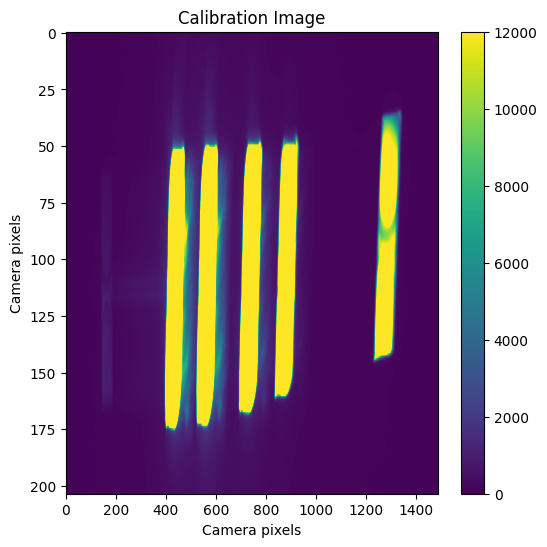

In [10]:
# plot averaged image
img_to_unskew = np.array(img2d)
f,ax = plt.subplots(figsize=(6,6))
i = ax.imshow(img_to_unskew, aspect='auto', vmin=0, vmax=12000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Calibration Image')
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

In [11]:
# If image isn't plotting, use this cell to confirm image isn't empty. Otherwise ignore this cell
print(f"img2d shape: {img2d.shape}")
print(f"img2d min: {img2d.min()}, max: {img2d.max()}")
print(f"img2d dtype: {img2d.dtype}")

img2d shape: (204, 1488)
img2d min: 95.649, max: 13615.512
img2d dtype: float64


In [12]:
# Extract rotation of image to flatten spectrum
# Find laser positions (horizontally)
h_orig_line = np.mean(img_to_unskew,axis=0) # average the image vertically, laser spots will appear as peaks in a horizontal 1D profile
h_orig_laser_pix, _ = find_peaks(h_orig_line, height=2000, distance=100) #find peaks brighter than 2000 and at least 100 pixels apart

# Find laser positions (vertically)
count = 0 # Initialize counter for laser number
sat_val = 12000 # Set intensity threshold for pixels that contain lasers
v_orig_laser_pix = np.zeros(np.size(h_orig_laser_pix)) # Initialize array to store vertical positions of each laser

for l in h_orig_laser_pix: # Run the loop for each laser's horizontal position 'l'
    v_orig_line = img_to_unskew[:,l] # Extract a vertical column from the original calibration image at each position 'l'
    v_orig_line[v_orig_line<sat_val] = 0 # Set all pixels below the sat_val threshold to 0 to isolate the brightest spots
    idx = np.nonzero(np.diff(v_orig_line))[0] # Find indices where bright spots transition to 0 (top and bottom edges of the laser spot)
    v_orig_laser_pix[count] = np.round((idx[0]+idx[-1])/2) # Find the laser's vertical midpoint by averaging its top and bottom edges
    count +=1 # Increase the laser counter by 1
    
print(h_orig_laser_pix)
print(v_orig_laser_pix)

[ 432  561  729  870 1277]
[112. 112. 108. 105.  92.]


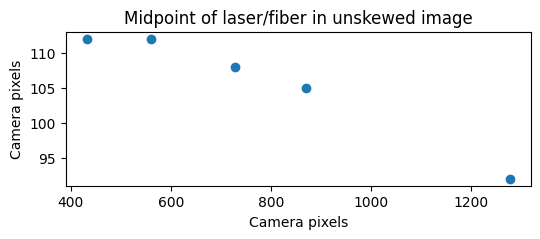

In [13]:
# Plot midpoints of each laser
f, ax = plt.subplots(figsize=(6,2))
ax.plot(h_orig_laser_pix,v_orig_laser_pix,'o')
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Midpoint of laser/fiber in unskewed image')
plt.show()

Rotation angle:
-0.9156080256587755

original image dimensions (height, width):
(204, 1488)

unskewed image dimensions (height, width):
(204, 1488)


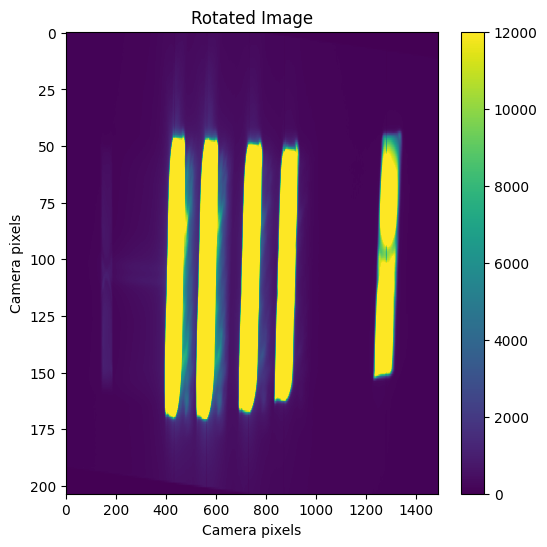

In [14]:
# Calculate rotation angle needed to unskew calibration image
# Find the tilt angle between the first and second-to-last laser
theta_r = np.rad2deg(np.arctan((v_orig_laser_pix[-2]-v_orig_laser_pix[0])/(h_orig_laser_pix[-2]-h_orig_laser_pix[0])))
# v_orig_laser_pix = vertical distance (rise); h_orig_laser_pix = horizontal distance (run); arctan(rise/run) = angle in radians
print('Rotation angle:')
print(theta_r)

# Rotate image by the calculated angle using openCV
rows,cols = img_to_unskew.shape 
M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),theta_r,1) # create a rotation transformation matrix
# (cols-1)/2.0,(rows-1)/2.0) = image center; theta_r = tilt angle; 1 = scale (no scaling, just rotation)
img_rotated = cv.warpAffine(img_to_unskew,M,(cols,rows)) # apply the rotation transformation to unskew the image

# Confirm that rotation did not alter overall height/width of the image
print('\noriginal image dimensions (height, width):')
print(img2d.shape) 
print('\nunskewed image dimensions (height, width):')
print(img_rotated.shape) 

# Plot the rotated/unskewed image
f,ax = plt.subplots(figsize=(6,6))
i = ax.imshow(img_rotated, aspect='auto', vmin=0, vmax=12000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Rotated Image')
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

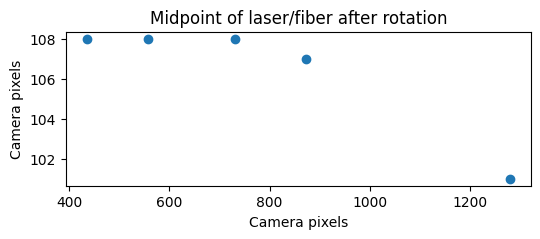


Horizontal midpoint of each laser:
[ 435  558  732  873 1280]

Vertical midpoint of each laser:
[108 108 108 107 101]


In [15]:
# Check position of lasers in rotated image
# Find laser positions (horizontally)
h_line = np.mean(img_rotated,axis=0)
h_laser_pix, _ = find_peaks(h_line, height=2000, distance=100)

# Find laser positions (vertically)
count = 0
v_laser_pix = np.zeros(np.size(h_laser_pix))
for l in h_laser_pix:
    v_line = img_rotated[:,l]
    v_line[v_line<sat_val] = 0
    idx = np.nonzero(np.diff(v_line))[0]
    v_laser_pix[count] = np.round((idx[0]+idx[-1])/2)
    count +=1
v_laser_pix = v_laser_pix.astype(int)

# Plot midpoints of each laser after rotation
f, ax = plt.subplots(figsize=(6,2))
ax.plot(h_laser_pix,v_laser_pix,'o')
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Midpoint of laser/fiber after rotation')
plt.show()

print('\nHorizontal midpoint of each laser:')
print(h_laser_pix)
print('\nVertical midpoint of each laser:')
print(v_laser_pix)

## Perform an affine transformation to straighten the spectrum
The fibers have a slight skew and are not perfectly straight up and down. The affine transformation is calculated by shifting the top left edge of two of the fibers to align with their respective bottom left edges. This transformation is then applied across the entire image.
- affine transformation = a type of linear mapping that preserves points, straight lines, and planes, but not necessarily distances or angles
- preserves collinearity and ratios of distances along a line


### Function definitions

In [16]:
def analyze_laser(img_rotated, h_laser_pix, use_laser, sat_val, fiber_width=60):
    """Finds and plots the top/bottom edges of a fiber for a given laser."""
    
    # --- Vertical boundaries ---
    v_line = img_rotated[:, h_laser_pix[use_laser]] # extract one vertical column of pixel intensities at the laser's x-position
    v_line[v_line < sat_val] = 0 # set values below the intensity threshold to zero
    idx = np.nonzero(np.diff(v_line))[0] # find locations where intensity changes (edge of laser)
    v_width = [int(idx[0]), int(idx[-1])] # store the top and bottom y-coordinates of the laser
    
    # --- Horizontal boundaries (top and bottom) ---
    h_width = []
    for position, label, offset in zip(
        [v_width[0] + 5, v_width[1] - 5],
        ["Top", "Bottom"],
        ["h_top", "h_bot"]
    ):
        # Extract horizontal cross-section
        h_line = img_rotated[
            position,
            h_laser_pix[use_laser] - fiber_width : h_laser_pix[use_laser] + fiber_width
        ]
        h_line[h_line < sat_val] = 0
        h_edges = np.nonzero(np.diff(h_line))[0]
        h_edge = int(h_edges[0])

        # --- Plot for visualization --- 
        f, ax = plt.subplots(figsize=(4, 2))
        ax.plot(h_line)
        ax.set(
            xlabel="Camera pixels",
            ylabel="Saturation intensity",
            title=f"Laser {use_laser + 1} Fiber {label}"
        )
        plt.show()

        # Convert to absolute coordinates
        h_width.append(int(h_laser_pix[use_laser] - fiber_width + h_edge))

    # --- Print summary ---
    print(f"Laser {use_laser + 1}")
    print(f"  Vertical pixel indices (top, bottom): {v_width}")
    print(f"  Horizontal pixel indices (top left, bottom left): {h_width}\n\n")
    
    return v_width, h_width

    

In [17]:
def check_laser_post_affine(img, h_laser_pix, use_laser, sat_val, fiber_width=60):
    """ Check the top and bottom of a laser fiber in the post-affine transformed image.
    Parameters
    ----------
    img : 2D array
        The affine-transformed image (img_final)
    h_laser_pix : list or array
        X positions of lasers
    use_laser : int
        Index of the laser to analyze
    fiber_width : int
        Half-width of the horizontal crop around the laser
    sat_val : int
        Threshold value to zero out background pixels
    
    Returns
    -------
    v_width : list of int
        Vertical pixel indices [top, bottom] of the laser
    h_width : list of int
        Horizontal pixel indices [top-left, bottom-left] of the laser
    """
    
    # --- Vertical coordinates ---
    v_line = img[:, h_laser_pix[use_laser]]          # vertical slice at laser x-position
    v_line[v_line < sat_val] = 0                     # threshold low intensity
    idx = np.nonzero(np.diff(v_line))[0]             # edges along y-axis
    v_width = [int(idx[0]), int(idx[-1])]            # top and bottom y-coordinates

    # --- Horizontal coordinates ---
    # Top edge
    h_line_top = img[v_width[0]+5, h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
    h_line_top[h_line_top < sat_val] = 0
    # h_top_idx = np.nonzero(np.diff(h_line_top))[0][0]  # first edge
    # h_top = int(h_laser_pix[use_laser] - fiber_width + h_top_idx)
    h_top_idx = np.nonzero(np.diff(h_line_top))[0]
    h_top = int(h_top_idx[0])

    # Bottom edge
    h_line_bot = img[v_width[1]-5, h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
    h_line_bot[h_line_bot < sat_val] = 0
    # h_bot_idx = np.nonzero(np.diff(h_line_bot))[0][0]
    # h_bot = int(h_laser_pix[use_laser] - fiber_width + h_bot_idx)
    h_bot_idx = np.nonzero(np.diff(h_line_bot))[0]
    h_bot = int(h_bot_idx[0])

    #h_width = [h_top, h_bot]
    # Convert to absolute coordinates
    h_width = [int(h_laser_pix[use_laser]-fiber_width + h_top),
               int(h_laser_pix[use_laser]-fiber_width + h_bot)]

    # --- Plotting ---
    for line, name in zip([h_line_top, h_line_bot], ["Top", "Bottom"]):
        f, ax = plt.subplots(figsize=(4,2))
        ax.plot(line)
        ax.set(xlabel='Camera pixels', ylabel='Saturation intensity', title=f'Laser {use_laser + 1} Fiber {name}')
        plt.show()
        
     # --- Print summary ---
    print(f"\nLaser {use_laser + 1}")
    print(f"  Vertical pixel indices (top, bottom): {v_width}")
    print(f"  Horizontal pixel indices (top left, bottom left): {h_width}")

    return v_width, h_width


### Perform affine transformation

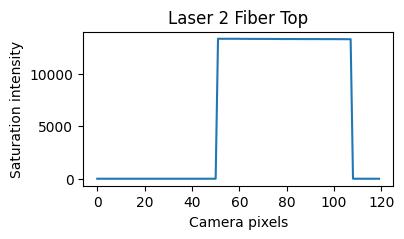

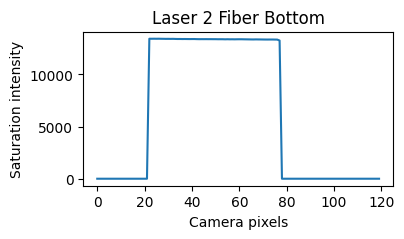

Laser 2
  Vertical pixel indices (top, bottom): [47, 170]
  Horizontal pixel indices (top left, bottom left): [548, 519]




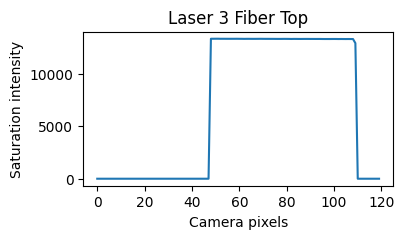

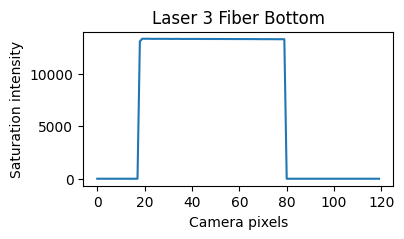

Laser 3
  Vertical pixel indices (top, bottom): [49, 166]
  Horizontal pixel indices (top left, bottom left): [719, 689]


[47, 170] [548, 519] [49, 166] [719, 689]


In [18]:
# Find the coordinates of the top and bottom of the fiber image for the given lasers
# for laser_idx in [1, 2]:
#     analyze_laser(img_rotated, h_laser_pix, laser_idx, sat_val, fiber_width=60)

# Find fiber coordinates for laser 2
use_laser_1 = 1
v_width, h_width = analyze_laser(img_rotated, h_laser_pix, use_laser_1, sat_val, fiber_width=60)

# Find fiber coordinates for laser 3
use_laser_2 = 2
v_width2, h_width2 = analyze_laser(img_rotated, h_laser_pix, use_laser_2, sat_val, fiber_width=60)

print(v_width, h_width, v_width2, h_width2)

[548, 47] [519, 170] [719, 49] [519, 47] [519, 170] [689, 49]


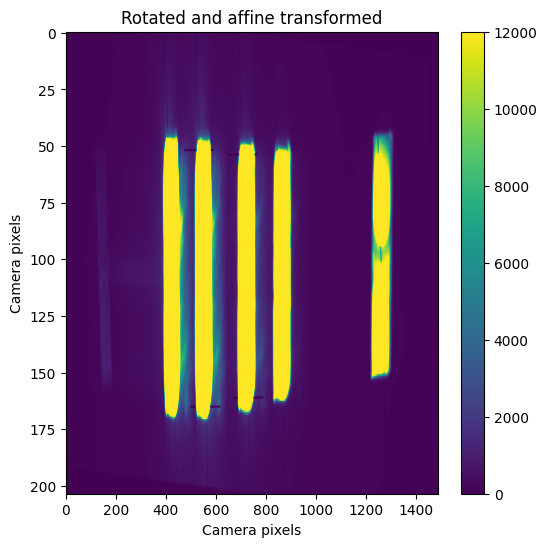

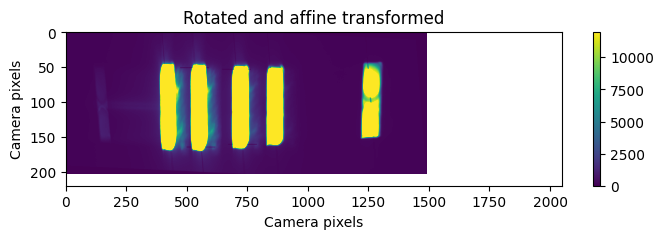

In [19]:
# Perform the affine transformation
# v_width[0] = bottom of fiber, v_width[1] = top of fiber, h_width[0] = left side of fiber, h_width[1] = right side of fiber

# Specify the location of three points in the source image
pt1 = [h_width[0], v_width[0]] # top-left corner of 1st fiber
pt2 = [h_width[1], v_width[1]] # bottom-left corner of 1st fiber
pt3 = [h_width2[0], v_width2[0]] # top-left corner of 2nd fiber

# Specify where you want those 3 points to map onto in the transformed image
pt4 = [h_width[1], v_width[0]] # map top-left of 1st fiber to bottom-left x-position (shear/stretch top in x direction)
pt5 = [h_width[1], v_width[1]] # map bottom-left of 1st fiber to bottom-left x-position (no transformation)
pt6 = [h_width2[1], v_width2[0]] # map top-left of 2nd fiber to bottom-left x-position (shear/stretch top in x direction)


print(pt1, pt2, pt3, pt4, pt5, pt6)

rows,cols = img_rotated.shape # get height and width of the image to define the output size in warpAffine
pts1 = np.float32([pt1, pt2, pt3]) # source points (from original image)
pts2 = np.float32([pt4, pt5, pt6]) # destination points (where those points should end up in the output image)
M = cv.getAffineTransform(pts1,pts2) # compute a 2x3 affine transformation matrix
img_final = cv.warpAffine(img_rotated,M,(cols,rows)) # apply the transfomration to the whole image

f,ax = plt.subplots(figsize=(6,6))
i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=12000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Rotated and affine transformed')
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

f,ax = plt.subplots(figsize=(8,2))
i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=12000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels',  title='Rotated and affine transformed', xlim=[0,2048], ylim=[pt5[1]+50,pt6[1]-50])
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

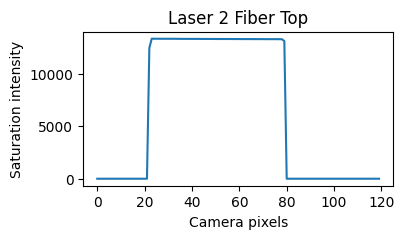

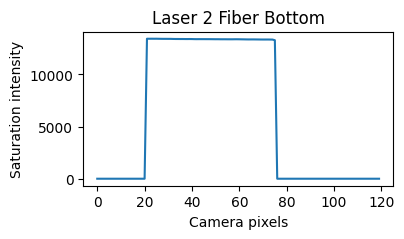


Laser 2
  Vertical pixel indices (top, bottom): [48, 170]
  Horizontal pixel indices (top left, bottom left): [519, 518]


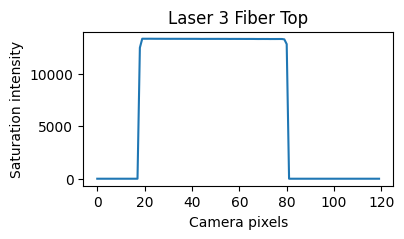

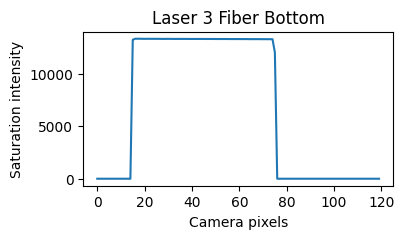


Laser 3
  Vertical pixel indices (top, bottom): [50, 166]
  Horizontal pixel indices (top left, bottom left): [689, 686]


([50, 166], [689, 686])

In [20]:
# Check that transformation aligned laser top and bottom
# Check the first laser used
check_laser_post_affine(img_final, h_laser_pix, use_laser_1, sat_val, fiber_width=60)

# Check the second laser used
check_laser_post_affine(img_final, h_laser_pix, use_laser_2, sat_val, fiber_width=60)

### non-function version of v_width h_width calculations

In [21]:
# # Extract rotation of slit to straighten the spectrum

# # Find the coordinates of the top and bottom of the fiber image for a given laser
# use_laser = 1 # pick the second laser to evaluate slit straightening

# # Calculate the y-coordinates of the selected laser
# v_line = img_rotated[:,h_laser_pix[use_laser]] # extract one vertical column of pixel intensities at the laser's x-position
# v_line[v_line<sat_val] = 0 # set values below the intensity threshold to zero
# idx = np.nonzero(np.diff(v_line))[0] # find locations where intensity changes (edge of laser)
# v_width = [idx[0],idx[-1]] # store the top and bottom y-coordinates of the laser

# fiber_width = 60 # used to crop x-axis to area around the fiber

# # Calculate the x-coordinates for the top edge of the selected laser
# # take a horizontal cross-section slightly below (v_width[0]+5) the top of the bright region
# # left/right indices of the cross-section are a fiber_width distance away from the midpoint on each side
# h_line_top = img_rotated[v_width[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width] 
# h_line_top[h_line_top<sat_val] = 0 # zero out low intensities
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0] # store the top and bottom x-coordinates of the laser
# h_top = h_line_top_width[0] # store the first edge index as h_top

# # Plot the top edge of the fiber
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title=f'Laser {use_laser + 1} Fiber Top')
# plt.show()

# # Repeat the process for the bottom edge of the selected laser
# # take a horizontal cross-section slightly above the bottom of the bright region from -fiber_width to +fiber_width around the midpoint
# h_line_bot = img_rotated[v_width[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]

# # Plot the bottom edge of the fiber
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title=f'Laser {use_laser + 1} Fiber Bottom')
# plt.show()

# # Convert the horizontal coordinates from the relative cropped window to absolute pixel coordinates on the full image
# h_width = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot] 

# # Print the vertical and horizontal coordinates in pixel indices
# int_v_width = [int(x) for x in v_width] # convert from NumPy's numeric type to native Python int
# int_h_width = [int(x) for x in h_width] # convert from NumPy's numeric type to native Python int
# print(f'\nVertical pixel indices (top, bottom) for laser {use_laser + 1}:')

# print(int_v_width)
# print(f'\nHorizontal pixel indices (left, right) for laser {use_laser + 1}:')
# print(int_h_width)

# # Repeat above process on the third laser
# use_laser = 2

# # Calculate the y-coordinates
# v_line = img_rotated[:,h_laser_pix[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width2 = [idx[0],idx[-1]]

# # Calculate the x-coordinates for the fiber's top edge
# h_line_top = img_rotated[v_width2[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_top[h_line_top<sat_val] = 0
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
# h_top = h_line_top_width[0]

# # Plot the top edge of the fiber
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title=f'Laser {use_laser + 1} Fiber Top')
# plt.show()

# # Calculate the x-coordinates for the fiber's bottom edge
# h_line_bot = img_rotated[v_width2[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]

# # Plot the bottom edge of the fiber
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title=f'Laser {use_laser + 1} Fiber Bottom')
# plt.show()
# h_width2 = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot]

# # Print the vertical and horizontal coordinates in pixel indices
# int_v_width2 = [int(x) for x in v_width2] # convert from NumPy's numeric type to native Python int
# int_h_width2 = [int(x) for x in h_width2] # convert from NumPy's numeric type to native Python int
# print(f'\nVertical pixel indices (top, bottom) for laser {use_laser + 1}:')

# print(int_v_width2)
# print(f'\nHorizontal pixel indices (left, right) for laser {use_laser + 1}:')
# print(int_h_width2)

In [22]:
# # Extract rotation of slit to straighten the spectrum
# use_laser = 1

# # Calculate the y-coordinates
# v_line = img_rotated[:,h_laser_pix[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width = [idx[0],idx[-1]]

# fiber_width = 60

# # Calculate the x-coordinates
# h_line_top = img_rotated[v_width[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_top[h_line_top<sat_val] = 0
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
# h_top = h_line_top_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber top')
# plt.show()

# h_line_bot = img_rotated[v_width[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber bottom')
# plt.show()
# h_width = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot]

# print(v_width)
# print(h_width)

# use_laser = 2
# # Calculate the y-coordinates
# v_line = img_rotated[:,h_laser_pix[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width2 = [idx[0],idx[-1]]

# # Calculate the x-coordinates
# h_line_top = img_rotated[v_width2[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_top[h_line_top<sat_val] = 0
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
# h_top = h_line_top_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber top')
# plt.show()

# h_line_bot = img_rotated[v_width2[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber bottom')
# plt.show()
# h_width2 = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot]

# print(v_width2)
# print(h_width2)


In [23]:
# fiber_width=60
# # Check laser top and bottom after affine transformation
# use_laser = 2
# # Calculate the y-coordinates
# v_line = img_final[:,h_laser_pix[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width = [idx[0],idx[-1]]
# # Calculate the x-coordinates
# h_line_top = img_final[v_width[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_top[h_line_top<sat_val] = 0
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
# h_top = h_line_top_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber top')
# plt.show()
# h_line_bot = img_final[v_width[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber bottom')
# plt.show()

# h_width = [int(h_laser_pix[use_laser]-fiber_width + h_top),
#                int(h_laser_pix[use_laser]-fiber_width + h_bot)]

# print(v_width)
# print(h_width)

## Identify relative pixel location of each fiber

In [24]:
# Find pixels that correspond to fiber 1 and fiber 2
# Create a 1D array representing mean brightness at each x-position
h_line_new = np.mean(img_final,axis=0) # calculate the average intensity along each column of the final image
h_laser_pix_new, _ = find_peaks(h_line_new, height=2000, distance=100) # identify x-positions of peaks above 2000 and at least 100 pixels apart
v_line = img_final[:,h_laser_pix_new[use_laser_2]]
v_line[v_line < sat_val] = 0
idx = np.nonzero(np.diff(v_line))[0]
v_width = [int(idx[0]), int(idx[-1])]
print(f"Laser {use_laser_2+1} \nVertical pixel indices (top, bottom): {v_width}")

# Adjust the top and bottom of each fiber slightly to define subregions inside the fiber
# Define vertical bounds of the first fiber
fiber1_top = v_width[0] + 20 # 20 pixels below the top edge
fiber1_bottom = v_width[0] + 50 - 10 # 40 pixels below the top edge
# Define vertical bounds of the second fiber
fiber2_top = v_width[1] - 50 + 10 # 40 pixels above the bottom edge
fiber2_bottom = v_width[1] - 20 # 20 pixels above the bottom edge

# Store the vertical boundaries of each fiber
fiber1 = [fiber1_top, fiber1_bottom]
fiber2 = [fiber2_top, fiber2_bottom]
print(f"\nLaser {use_laser_2+1}")
print(f"Fiber 1 boundaries (top, bottom): {fiber1}")
print(f"Fiber 2 boundaries (top, bottom): {fiber2}")

print(h_laser_pix_new)

Laser 3 
Vertical pixel indices (top, bottom): [49, 166]

Laser 3
Fiber 1 boundaries (top, bottom): [69, 89]
Fiber 2 boundaries (top, bottom): [126, 146]
[ 430  543  716  853 1250]


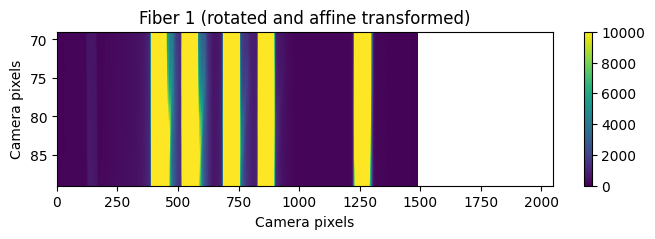

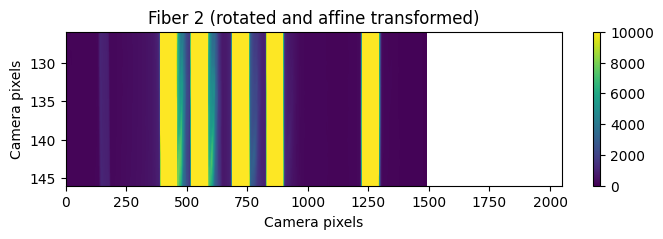

In [19]:
# Plot the sections of the calibration image containing each fiber
# Fiber 1 location
f,ax = plt.subplots(figsize=(8,2))
i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=10000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels',  title='Fiber 1 (rotated and affine transformed)', xlim=[0,2048], ylim=[fiber1[1],fiber1[0]])
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

# Fiber 2 location
f,ax = plt.subplots(figsize=(8,2))
i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=10000)
ax.set(xlabel='Camera pixels', ylabel='Camera pixels',  title='Fiber 2 (rotated and affine transformed)', xlim=[0,2048], ylim=[fiber2[1],fiber2[0]])
ax.grid(False)
f.colorbar(i,ax=ax)
plt.show()

In [ ]:
# Save the affine transformed points and fiber locations
pt1[0] = int(pt1[0] + Xoffset)
pt2[0] = int(pt2[0] + Xoffset)
pt3[0] = int(pt3[0] + Xoffset)
pt4[0] = int(pt4[0] + Xoffset)
pt5[0] = int(pt5[0] + Xoffset)
pt6[0] = int(pt6[0] + Xoffset)
pt1[1] = int(pt1[1] + Yoffset)
pt2[1] = int(pt2[1] + Yoffset)
pt3[1] = int(pt3[1] + Yoffset)
pt4[1] = int(pt4[1] + Yoffset)
pt5[1] = int(pt5[1] + Yoffset)
pt6[1] = int(pt6[1] + Yoffset)

fiber1[0] = int(fiber1[0] + Yoffset)
fiber1[1] = int(fiber1[1] + Yoffset)
fiber2[0] = int(fiber2[0] + Yoffset)
fiber2[1] = int(fiber2[1] + Yoffset)

In [ ]:
print(path)

In [ ]:
print(paths)

In [ ]:
# Save transformed image for wavelength calibration
img_final = img_final.astype(int)
results_dir = Path('/results/')
results_dir.mkdir(parents=True, exist_ok=True)  # ensure folder exists

output_file = results_dir / "CalibrationImage.tiff"
cv.imwrite(str(output_file), img_final)

with open(results_dir / 'calibration.txt','w') as f:
    f.write(f'rot_tform_thetaR = {theta_r}\n')
    f.write(f'aff_tform_pt1 = {pt1}\n')
    f.write(f'aff_tform_pt2 = {pt2}\n')
    f.write(f'aff_tform_pt3 = {pt3}\n')
    f.write(f'aff_tform_pt4 = {pt4}\n')
    f.write(f'aff_tform_pt5 = {pt5}\n')
    f.write(f'aff_tform_pt6 = {pt6}\n')
    f.write(f'fiber1_pixels = {fiber1}\n')
    f.write(f'fiber2_pixels = {fiber2}\n')
    f.write(f'calib_Xoffset = {Xoffset}\n')

In [ ]:
os.listdir(data_dir)[0]

## Smrithi's original code

In [ ]:
# import pandas as pd
# import numpy as np
# import os
# import glob
# from config import load_config
# paths = load_config(dataset_key='all')
# from natsort import natsorted
# from skimage import io
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks
# import cv2 as cv
# from PIL import Image

In [ ]:
# # Load calibration sequence images and metadata
# path = paths['raw_data']
# path = str(path)
# path = os.path.join(path,'CalibrationFiles')
# metadata_file = glob.glob(os.path.join(path,'*.csv'))
# print(metadata_file)
# metadata = pd.read_csv(metadata_file[0])
# files = os.listdir(path)
# print(files)
# tiff_dir = os.path.join(path,files[1])
# tiff_files = os.listdir(tiff_dir)
# tiff_files = np.array(natsorted(tiff_files))
# print(tiff_files)
# tiff_file_path = os.path.join(tiff_dir,tiff_files[0])
# tiff = Image.open(tiff_file_path)
# image_sequence = []
# while True:
#     try:
#         image_sequence.append(np.array(tiff))
#         tiff.seek(tiff.tell() + 1)
#     except EOFError:
#         break


In [ ]:
# # Average all frames 
# img = np.array(image_sequence)
# img2d = img.mean(axis=0)
# print(img2d.shape)
# width = metadata.Width[0] # Camera pixels in x direction
# print(width)
# Xoffset = metadata.XOffset[0] # Start of camera pixels in x direction
# print(Xoffset)
# height = metadata.Height[0] # Camera pixels in y direction
# print(height)
# Yoffset = metadata.YOffset[0] # Start of camera pixels in y direction
# print(Yoffset)
# img_to_unskew = np.array(img2d)
# f,ax = plt.subplots(figsize=(6,6))
# i = ax.imshow(img_to_unskew, aspect='auto', vmin=0, vmax=12000)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Calibration Image')
# ax.grid(False)
# f.colorbar(i,ax=ax)
# plt.show()

In [ ]:
# # Extract rotation of image to flatten spectrum
# h_line = np.mean(img_to_unskew,axis=0)
# h_laser_pix, _ = find_peaks(h_line, height=2000, distance=100)
# count = 0
# sat_val = 12000 # Threshold for pixels that contain lasers
# v_laser_pix = np.zeros(np.size(h_laser_pix))
# for l in h_laser_pix:
#     v_line = img_to_unskew[:,l]
#     v_line[v_line<sat_val] = 0
#     idx = np.nonzero(np.diff(v_line))[0]
#     v_laser_pix[count] = np.round((idx[0]+idx[-1])/2)
#     count +=1

# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_laser_pix,v_laser_pix,'o')
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Mid point of laser/fiber image')
# plt.show()

# # Angle to rotate
# theta_r = np.rad2deg(np.arctan((v_laser_pix[-2]-v_laser_pix[0])/(h_laser_pix[-2]-h_laser_pix[0])))
# print(theta_r)

# # Rotation using openCV
# rows,cols = img_to_unskew.shape
# M = cv.getRotationMatrix2D(((cols-1)/2.0,(rows-1)/2.0),theta_r,1)
# img_rotated = cv.warpAffine(img_to_unskew,M,(cols,rows))
# img_rotated.shape
# f,ax = plt.subplots(figsize=(6,6))
# i = ax.imshow(img_rotated, aspect='auto', vmin=0, vmax=12000)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Rotated Imge')
# ax.grid(False)
# f.colorbar(i,ax=ax)
# plt.show()

# # Check position of lasers in rotated image
# h_line = np.mean(img_rotated,axis=0)
# h_laser_pix, _ = find_peaks(h_line, height=2000, distance=100)
# count = 0
# v_laser_pix = np.zeros(np.size(h_laser_pix))
# for l in h_laser_pix:
#     v_line = img_rotated[:,l]
#     v_line[v_line<sat_val] = 0
#     idx = np.nonzero(np.diff(v_line))[0]
#     v_laser_pix[count] = np.round((idx[0]+idx[-1])/2)
#     count +=1
# v_laser_pix = v_laser_pix.astype(int)
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_laser_pix,v_laser_pix,'o')
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Mid point of laser/fiber after rotation')
# plt.show()
# print(h_laser_pix)
# print(v_laser_pix)


In [ ]:
# # Extract rotation of slit to straighten the spectrum
# use_laser = 1

# # Calculate the y-coordinates
# v_line = img_rotated[:,h_laser_pix[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width = [idx[0],idx[-1]]

# fiber_width = 60

# # Calculate the x-coordinates
# h_line_top = img_rotated[v_width[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_top[h_line_top<sat_val] = 0
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
# h_top = h_line_top_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber top')
# plt.show()

# h_line_bot = img_rotated[v_width[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber bottom')
# plt.show()
# h_width = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot]

# print(v_width)
# print(h_width)

# use_laser = 2
# # Calculate the y-coordinates
# v_line = img_rotated[:,h_laser_pix[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width2 = [idx[0],idx[-1]]

# # Calculate the x-coordinates
# h_line_top = img_rotated[v_width2[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_top[h_line_top<sat_val] = 0
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
# h_top = h_line_top_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber top')
# plt.show()

# h_line_bot = img_rotated[v_width2[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber bottom')
# plt.show()
# h_width2 = [h_laser_pix[use_laser]-fiber_width+h_top, h_laser_pix[use_laser]-fiber_width+h_bot]

# print(v_width2)
# print(h_width2)


In [ ]:
# # Affine transformation
# pt1 = [h_width[0], v_width[0]]
# pt2 = [h_width[1], v_width[1]]
# pt3 = [h_width2[0], v_width2[0]]
# pt4 = [h_width[1], v_width[0]]
# pt5 = [h_width[1], v_width[1]]
# pt6 = [h_width2[1], v_width2[0]]
# print(pt1, pt2, pt3, pt4, pt5, pt6)

# rows,cols = img_rotated.shape
# pts1 = np.float32([pt1, pt2, pt3])
# pts2 = np.float32([pt4, pt5, pt6])
# M = cv.getAffineTransform(pts1,pts2)
# img_final = cv.warpAffine(img_rotated,M,(cols,rows))

# f,ax = plt.subplots(figsize=(6,6))
# i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=12000)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Rotated and affine transformed')
# ax.grid(False)
# f.colorbar(i,ax=ax)
# plt.show()

# f,ax = plt.subplots(figsize=(8,2))
# i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=12000)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels',  title='Rotated and affine transformed', xlim=[0,2048], ylim=[pt5[1]+50,pt6[1]-50])
# ax.grid(False)
# f.colorbar(i,ax=ax)
# plt.show()


In [ ]:
# # Check laser top and bottom after affine transformation
# use_laser = 2
# # Calculate the y-coordinates
# v_line = img_final[:,h_laser_pix[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width = [idx[0],idx[-1]]
# # Calculate the x-coordinates
# h_line_top = img_final[v_width[0]+5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_top[h_line_top<sat_val] = 0
# h_line_top_width = np.nonzero(np.diff(h_line_top))[0]
# h_top = h_line_top_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_top)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber top')
# plt.show()
# h_line_bot = img_final[v_width[1]-5,h_laser_pix[use_laser]-fiber_width:h_laser_pix[use_laser]+fiber_width]
# h_line_bot[h_line_bot<sat_val] = 0
# h_line_bot_width = np.nonzero(np.diff(h_line_bot))[0]
# h_bot = h_line_bot_width[0]
# f, ax = plt.subplots(figsize=(6,2))
# ax.plot(h_line_bot)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels', title='Fiber bottom')
# plt.show()


In [ ]:
# # Find pixels that correspond to fiber1 and fiber2
# use_laser = 2
# h_line_new = np.mean(img_final,axis=0)
# h_laser_pix_new, _ = find_peaks(h_line_new, height=2000, distance=100)
# v_line = img_final[:,h_laser_pix_new[use_laser]]
# v_line[v_line<sat_val] = 0
# idx = np.nonzero(np.diff(v_line))[0]
# v_width = [idx[0],idx[-1]]
# print(v_width)

# fiber1_top = v_width[0]+20
# fiber1_bottom = v_width[0]+50-10
# fiber2_top = v_width[1]-50+10
# fiber2_bottom = v_width[1]-20

# fiber1 = [fiber1_top, fiber1_bottom]
# fiber2 = [fiber2_top, fiber2_bottom]
# print(fiber1, fiber2)

# # Fiber1 location
# f,ax = plt.subplots(figsize=(8,2))
# i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=10000)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels',  title='Rotated and affine transformed', xlim=[0,2048], ylim=[fiber1[1],fiber1[0]])
# ax.grid(False)
# f.colorbar(i,ax=ax)
# plt.show()

# # Fiber2 location
# f,ax = plt.subplots(figsize=(8,2))
# i = ax.imshow(img_final, aspect='auto', vmin=0, vmax=10000)
# ax.set(xlabel='Camera pixels', ylabel='Camera pixels',  title='Rotated and affine transformed', xlim=[0,2048], ylim=[fiber2[1],fiber2[0]])
# ax.grid(False)
# f.colorbar(i,ax=ax)
# plt.show()

In [ ]:
# pt1[0] = pt1[0] + Xoffset
# pt2[0] = pt2[0] + Xoffset
# pt3[0] = pt3[0] + Xoffset
# pt4[0] = pt4[0] + Xoffset
# pt5[0] = pt5[0] + Xoffset
# pt6[0] = pt6[0] + Xoffset
# pt1[1] = pt1[1] + Yoffset
# pt2[1] = pt2[1] + Yoffset
# pt3[1] = pt3[1] + Yoffset
# pt4[1] = pt4[1] + Yoffset
# pt5[1] = pt5[1] + Yoffset
# pt6[1] = pt6[1] + Yoffset

# fiber1[0] = fiber1[0] + Yoffset
# fiber1[1] = fiber1[1] + Yoffset
# fiber2[0] = fiber2[0] + Yoffset
# fiber2[1] = fiber2[1] + Yoffset

# print(pt1, pt2, pt3, pt4, pt5, pt6, fiber1, fiber2)


In [ ]:
# # Save transformed image for wavelength calibration
# img_final = img_final.astype(int)
# path = paths['raw_data']
# output_file = f"{path}/CalibrationImage.tiff"
# cv.imwrite(output_file, img_final)

# with open(paths['raw_data'] / 'calibration.txt','w') as f:
#     f.write(f'rot_tform_thetaR = {theta_r}\n')
#     f.write(f'aff_tform_pt1 = {pt1}\n')
#     f.write(f'aff_tform_pt2 = {pt2}\n')
#     f.write(f'aff_tform_pt3 = {pt3}\n')
#     f.write(f'aff_tform_pt4 = {pt4}\n')
#     f.write(f'aff_tform_pt5 = {pt5}\n')
#     f.write(f'aff_tform_pt6 = {pt6}\n')
#     f.write(f'fiber1_pixels = {fiber1}\n')
#     f.write(f'fiber2_pixels = {fiber2}\n')
#     f.write(f'calib_Xoffset = {Xoffset}\n')
